In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [2]:
weather_data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/kozani_max_hourly_weather_2016_2024.csv")
weather_data.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,evapotranspiration,soil_temperature_0cm,soil_moisture_0_1cm,weathercode,city
0,2016-01-01T00:00,-4.1,45,-14.3,942.0,0,0.0,0.0,0.0,2.5,12.2,360,NaN,NaN,NaN,0,Kozani
1,2016-01-01T01:00,-4.2,45,-14.4,942.3,0,0.0,0.0,0.0,2.3,10.8,51,NaN,NaN,NaN,0,Kozani
2,2016-01-01T02:00,-4.4,46,-14.4,942.1,0,0.0,0.0,0.0,1.6,10.1,27,NaN,NaN,NaN,0,Kozani
3,2016-01-01T03:00,-4.5,46,-14.4,941.8,0,0.0,0.0,0.0,1.8,9.7,360,NaN,NaN,NaN,0,Kozani
4,2016-01-01T04:00,-5.2,46,-15.0,941.4,0,0.0,0.0,0.0,1.6,10.1,333,NaN,NaN,NaN,0,Kozani


In [3]:
kwh_data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/kwh_final_data_2016_to_2024.csv")
kwh_data

,Date,Kwh
0,01/01/2016 08:00,0.0000
1,01/01/2016 09:00,0.0025
2,01/01/2016 10:00,0.0157
3,01/01/2016 11:00,0.0242
4,01/01/2016 12:00,0.0290
...,...,...
54120,04/07/2024 19:00,0.0592
54121,04/07/2024 20:00,0.0085
54122,04/07/2024 21:00,0.0000
54123,04/07/2024 22:00,0.0000


In [4]:
weather_data["time"] = pd.to_datetime(weather_data["time"])
kwh_data["Date"] = pd.to_datetime(kwh_data["Date"], format="%d/%m/%Y %H:%M")

In [5]:
kwh_data.rename(columns={'Date': 'time', 'kWh': 'pv_production'}, inplace=True)

merged_df = pd.merge(weather_data, kwh_data, on='time', how='left')

merged_df["Kwh"] = merged_df["Kwh"].fillna(0)

merged_df.head(20)

,time,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,evapotranspiration,soil_temperature_0cm,soil_moisture_0_1cm,weathercode,city,Kwh
0,2016-01-01 00:00:00,-4.1,45,-14.3,942.0,0,0.0,0.0,0.0,2.5,12.2,360,NaN,NaN,NaN,0,Kozani,0.0000
1,2016-01-01 01:00:00,-4.2,45,-14.4,942.3,0,0.0,0.0,0.0,2.3,10.8,51,NaN,NaN,NaN,0,Kozani,0.0000
2,2016-01-01 02:00:00,-4.4,46,-14.4,942.1,0,0.0,0.0,0.0,1.6,10.1,27,NaN,NaN,NaN,0,Kozani,0.0000
3,2016-01-01 03:00:00,-4.5,46,-14.4,941.8,0,0.0,0.0,0.0,1.8,9.7,360,NaN,NaN,NaN,0,Kozani,0.0000
4,2016-01-01 04:00:00,-5.2,46,-15.0,941.4,0,0.0,0.0,0.0,1.6,10.1,333,NaN,NaN,NaN,0,Kozani,0.0000
5,2016-01-01 05:00:00,-5.3,46,-15.2,941.1,2,0.0,0.0,0.0,1.8,10.4,349,NaN,NaN,NaN,0,Kozani,0.0000
6,2016-01-01 06:00:00,-5.4,45,-15.3,941.1,0,0.0,0.0,0.0,1.6,11.2,27,NaN,NaN,NaN,0,Kozani,0.0000
7,2016-01-01 07:00:00,-5.5,45,-15.6,940.9,1,0.0,0.0,0.0,0.7,10.8,90,NaN,NaN,NaN,0,Kozani,0.0000
8,2016-01-01 08:00:00,-5.5,44,-15.8,941.3,1,0.0,0.0,0.0,1.0,10.8,135,NaN,NaN,NaN,0,Kozani,0.0000
9,2016-01-01 09:00:00,-5.6,44,-16.0,941.3,1,0.0,0.0,0.0,1.6,10.4,153,NaN,NaN,NaN,0,Kozani,0.0025


In [6]:
my_data = merged_df[["temperature_2m", "relative_humidity_2m", "windgusts_10m", "windspeed_10m", "winddirection_10m", "cloudcover", "shortwave_radiation", 
                   "weathercode", "Kwh"
                   ]]

my_data.shape

(72480, 9)

In [7]:
my_data["Kwh Target"] = my_data["Kwh"]
my_data.head()

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_1992/2643020446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_data["Kwh Target"] = my_data["Kwh"]


,temperature_2m,relative_humidity_2m,windgusts_10m,windspeed_10m,winddirection_10m,cloudcover,shortwave_radiation,weathercode,Kwh,Kwh Target
0,-4.1,45,12.2,2.5,360,0,0.0,0,0.0,0.0
1,-4.2,45,10.8,2.3,51,0,0.0,0,0.0,0.0
2,-4.4,46,10.1,1.6,27,0,0.0,0,0.0,0.0
3,-4.5,46,9.7,1.8,360,0,0.0,0,0.0,0.0
4,-5.2,46,10.1,1.6,333,0,0.0,0,0.0,0.0


In [8]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(my_data.iloc[:, :my_data.shape[1] - 1])
df_scaled = pd.DataFrame(df_scaled)
df_scaled.head(20)

,0,1,2,3,4,5,6,7,8
0,-1.940623,-0.974305,-0.599897,-0.927760,1.266015,-1.063495,-0.715400,-0.437672,-0.666859
1,-1.952130,-0.974305,-0.733209,-0.970884,-1.640676,-1.063495,-0.715400,-0.437672,-0.666859
2,-1.975145,-0.921544,-0.799865,-1.121817,-1.866438,-1.063495,-0.715400,-0.437672,-0.666859
3,-1.986653,-0.921544,-0.837954,-1.078694,1.266015,-1.063495,-0.715400,-0.437672,-0.666859
4,-2.067206,-0.921544,-0.799865,-1.121817,1.012032,-1.063495,-0.715400,-0.437672,-0.666859
5,-2.078714,-0.921544,-0.771298,-1.078694,1.162540,-1.013568,-0.715400,-0.437672,-0.666859
6,-2.090221,-0.974305,-0.695120,-1.121817,-1.866438,-1.063495,-0.715400,-0.437672,-0.666859
7,-2.101729,-0.974305,-0.733209,-1.315875,-1.273812,-1.038531,-0.715400,-0.437672,-0.666859
8,-2.101729,-1.027066,-0.733209,-1.251189,-0.850507,-1.038531,-0.715400,-0.437672,-0.666859
9,-2.113236,-1.027066,-0.771298,-1.121817,-0.681186,-1.038531,-0.715400,-0.437672,-0.655523


In [9]:
df_scaled.index = my_data.index
df_scaled = pd.concat([df_scaled, my_data["Kwh Target"]], axis= 1)
df_scaled.head(20)

,0,1,2,3,4,5,6,7,8,Kwh Target
0,-1.940623,-0.974305,-0.599897,-0.927760,1.266015,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
1,-1.952130,-0.974305,-0.733209,-0.970884,-1.640676,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
2,-1.975145,-0.921544,-0.799865,-1.121817,-1.866438,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
3,-1.986653,-0.921544,-0.837954,-1.078694,1.266015,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
4,-2.067206,-0.921544,-0.799865,-1.121817,1.012032,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
5,-2.078714,-0.921544,-0.771298,-1.078694,1.162540,-1.013568,-0.715400,-0.437672,-0.666859,0.0000
6,-2.090221,-0.974305,-0.695120,-1.121817,-1.866438,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
7,-2.101729,-0.974305,-0.733209,-1.315875,-1.273812,-1.038531,-0.715400,-0.437672,-0.666859,0.0000
8,-2.101729,-1.027066,-0.733209,-1.251189,-0.850507,-1.038531,-0.715400,-0.437672,-0.666859,0.0000
9,-2.113236,-1.027066,-0.771298,-1.121817,-0.681186,-1.038531,-0.715400,-0.437672,-0.655523,0.0025


In [10]:
df_scaled.head(30)

,0,1,2,3,4,5,6,7,8,Kwh Target
0,-1.940623,-0.974305,-0.599897,-0.927760,1.266015,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
1,-1.952130,-0.974305,-0.733209,-0.970884,-1.640676,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
2,-1.975145,-0.921544,-0.799865,-1.121817,-1.866438,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
3,-1.986653,-0.921544,-0.837954,-1.078694,1.266015,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
4,-2.067206,-0.921544,-0.799865,-1.121817,1.012032,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
5,-2.078714,-0.921544,-0.771298,-1.078694,1.162540,-1.013568,-0.715400,-0.437672,-0.666859,0.0000
6,-2.090221,-0.974305,-0.695120,-1.121817,-1.866438,-1.063495,-0.715400,-0.437672,-0.666859,0.0000
7,-2.101729,-0.974305,-0.733209,-1.315875,-1.273812,-1.038531,-0.715400,-0.437672,-0.666859,0.0000
8,-2.101729,-1.027066,-0.733209,-1.251189,-0.850507,-1.038531,-0.715400,-0.437672,-0.666859,0.0000
9,-2.113236,-1.027066,-0.771298,-1.121817,-0.681186,-1.038531,-0.715400,-0.437672,-0.655523,0.0025


In [11]:
df_scaled.shape

(72480, 10)

In [12]:

def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled, n=12)
reshaped_df.head(10)

,01,11,21,31,41,51,61,71,81,02,...,012,112,212,312,412,512,612,712,812,Kwh Target
0,-1.940623,-0.974305,-0.599897,-0.927760,1.266015,-1.063495,-0.7154,-0.437672,-0.666859,-1.952130,...,-2.055698,-1.132587,-0.599897,-1.078694,-0.323728,-1.063495,0.034428,-0.437672,-0.557124,0.0290
1,-1.952130,-0.974305,-0.733209,-0.970884,-1.640676,-1.063495,-0.7154,-0.437672,-0.666859,-1.975145,...,-1.906100,-1.501913,-0.457063,-1.078694,-0.323728,-1.038531,0.554717,-0.437672,-0.535358,0.0256
2,-1.975145,-0.921544,-0.799865,-1.121817,-1.866438,-1.063495,-0.7154,-0.437672,-0.666859,-1.986653,...,-1.791024,-1.449152,-0.352318,-1.251189,-0.003898,-1.063495,0.906677,-0.437672,-0.550776,0.0247
3,-1.986653,-0.921544,-0.837954,-1.078694,1.266015,-1.063495,-0.7154,-0.437672,-0.666859,-2.067206,...,-1.675948,-0.552219,-0.323751,-1.294313,0.165423,-1.038531,1.075005,-0.437672,-0.554857,0.0154
4,-2.067206,-0.921544,-0.799865,-1.121817,1.012032,-1.063495,-0.7154,-0.437672,-0.666859,-2.078714,...,-1.560872,-0.604979,-0.323751,-1.294313,0.165423,-1.038531,0.979364,-0.437672,-0.597028,0.0021
5,-2.078714,-0.921544,-0.771298,-1.078694,1.162540,-1.013568,-0.7154,-0.437672,-0.666859,-2.090221,...,-1.514842,-0.921544,-0.352318,-1.229627,-0.257881,-1.063495,0.658009,-0.437672,-0.657337,0.0000
6,-2.090221,-0.974305,-0.695120,-1.121817,-1.866438,-1.063495,-0.7154,-0.437672,-0.666859,-2.101729,...,-1.457304,-1.660195,-0.428496,-0.798388,-0.765846,-1.063495,0.175977,-0.437672,-0.666859,0.0000
7,-2.101729,-0.974305,-0.733209,-1.315875,-1.273812,-1.038531,-0.7154,-0.437672,-0.666859,-2.101729,...,-1.549365,-1.396391,-0.457063,-0.194653,-0.831694,-0.888753,-0.397871,-0.437672,-0.666859,0.0000
8,-2.101729,-1.027066,-0.733209,-1.251189,-0.850507,-1.038531,-0.7154,-0.437672,-0.666859,-2.113236,...,-1.641425,-1.185348,-0.428496,-0.065282,-0.747033,-0.564232,-0.707748,-0.382965,-0.666859,0.0000
9,-2.113236,-1.027066,-0.771298,-1.121817,-0.681186,-1.038531,-0.7154,-0.437672,-0.655523,-2.159267,...,-1.710471,-0.974305,-0.352318,-0.237777,-0.596525,0.184661,-0.715400,-0.328258,-0.666859,0.0000


In [13]:
reshaped_df.shape

(72468, 109)

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [15]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((57974, 108), (57974,), (7247, 108), (7247,), (7247, 108), (7247,))

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [17]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    
    #layers.Dense(512, activation='relu'),  
    #layers.BatchNormalization(),
    #layers.Dropout(0.2),
    
    layers.Dense(256, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'), 
    
    layers.Dense(32, activation='relu'), 
    #layers.Dropout(0.1),

    #layers.Dense(16, activation='relu'), 
    #layers.Dropout(0.1),

    layers.Dense(1, activation= "linear")
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        27,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,705 (284.00 KB)

 Trainable params: 71,937 (281.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [18]:
import time

start = time.time()
history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=100,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/100
3602/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.0492
Epoch 1: val_loss improved from inf to 0.00469, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
3624/3624 ━━━━━━━━━━━━━━━━━━━━ 3s 668us/step - loss: 0.0490 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 2/100
3545/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 0.0069
Epoch 2: val_loss improved from 0.00469 to 0.00439, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
3624/3624 ━━━━━━━━━━━━━━━━━━━━ 2s 665us/step - loss: 0.0069 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 3/100
3573/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0052
Epoch 3: val_loss improved from 0.00439 to 0.00428, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
3624/3624 ━━━━━━━━━━━━━━━━━━━━ 2s 655us/step - loss: 0.0052 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 4/100
3609/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - loss: 

In [19]:
print(f"{round((end - start) / 60, 4)} mins")

2.4073 mins


In [20]:
merged_df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,evapotranspiration,soil_temperature_0cm,soil_moisture_0_1cm,weathercode,city,Kwh
0,2016-01-01 00:00:00,-4.1,45,-14.3,942.0,0,0.0,0.0,0.0,2.5,12.2,360,NaN,NaN,NaN,0,Kozani,0.0
1,2016-01-01 01:00:00,-4.2,45,-14.4,942.3,0,0.0,0.0,0.0,2.3,10.8,51,NaN,NaN,NaN,0,Kozani,0.0
2,2016-01-01 02:00:00,-4.4,46,-14.4,942.1,0,0.0,0.0,0.0,1.6,10.1,27,NaN,NaN,NaN,0,Kozani,0.0
3,2016-01-01 03:00:00,-4.5,46,-14.4,941.8,0,0.0,0.0,0.0,1.8,9.7,360,NaN,NaN,NaN,0,Kozani,0.0
4,2016-01-01 04:00:00,-5.2,46,-15.0,941.4,0,0.0,0.0,0.0,1.6,10.1,333,NaN,NaN,NaN,0,Kozani,0.0


In [21]:
test_predictions_kwh = model.predict(x_test).flatten()
results_df = pd.DataFrame({"Predicted": test_predictions_kwh, "True": y_test})
results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df.index = merged_df.iloc[-7247:]["time"]
results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df['Predicted'] = results_df['Predicted'].apply(lambda x: max(x, 0))
results_df.head(20)

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step


,Predicted,True
time,,
2023-06-11 01:00:00,0.0001,0.0000
2023-06-11 02:00:00,0.0004,0.0000
2023-06-11 03:00:00,0.0000,0.0000
2023-06-11 04:00:00,0.0000,0.0000
2023-06-11 05:00:00,0.0000,0.0000
2023-06-11 06:00:00,0.0032,0.0039
2023-06-11 07:00:00,0.0196,0.0362
2023-06-11 08:00:00,0.1486,0.1453
2023-06-11 09:00:00,0.2853,0.5227


In [22]:
results_df.to_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Region1_Predictions.csv")

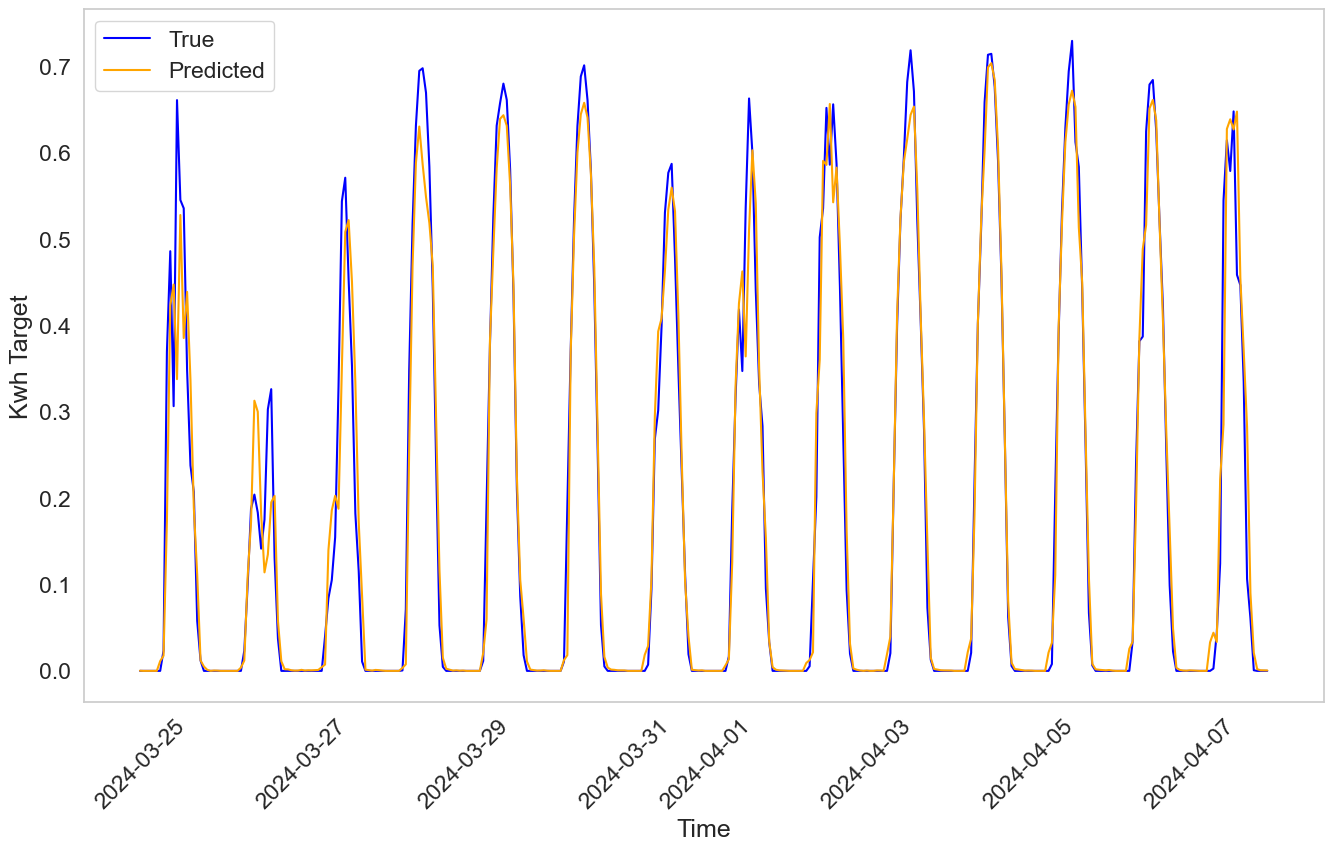

In [23]:
last_312_df = results_df.tail(336)
sns.set_style("whitegrid")

plt.figure(figsize=(16, 9))
sns.set_context("notebook", font_scale=1.5)
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
#plt.title('Predicted vs Actual Kwh Target')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [24]:
r2_score(results_df['Predicted'], results_df['True'])   #0.94558


0.946706762687085